# Action Factor Investigation - Importance Computing

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [1]:
%pwd

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article


/Users/lichao/opt/anaconda3/envs/ML/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "ClimateChanged_Dummy"

### Dataset building

In [18]:
knowledge_prob_matrix = pd.read_parquet('MLD01e_Data/processed/Knowledge_probability.parquet')

In [19]:
knowledge_prob_matrix.index = df_all.index

In [20]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix['Heard about Climate Change Probability']

In [21]:
knowledge_prob_matrix = pd.read_parquet('MLD01e_Data/processed/Awareness_probability.parquet')

In [22]:
knowledge_prob_matrix.index = df_all.index

In [23]:
df_all['Climate Change Awareness Probability'] = knowledge_prob_matrix['Climate Change Awareness Probability']

In [24]:
df_inuse = df_all[['RoadImprovementPast25',
                   'Climate Change Awareness Probability', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',

                    # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
]]

In [25]:
variname_readable = {'Climate Change Awareness Probability':'Climate Change Awareness Probability',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [26]:
variname_readable.update({'RoadImprovementPast25': 'Road Improvement in Past Dummy'})

In [27]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

## Hyperparameter

In [28]:
%ls MLD01e_Results

MLD01e_C01_KnowledgeFactorInvestigation.parquet*
MLD01e_C11_AwarenessFactorInvestigation_v1.parquet*
MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet*
MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet*
MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet*
MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet*
SummaryTable_ModelPerformance.xlsx
Table01_AllData_DataSummary.xlsx
Table01_DataSummaryForKnowledge_v1.xlsx
Table02_AccuracyTable_Knowledge_v1.xlsx
Table03_Importance_Knowledge_v1.xlsx
Table05_AccuracyTable_Logistic_Knowledge_v1.xlsx
Table11_DataSummaryAwareness_v1.xlsx
Table12_AccuracyTable_Awareness_v1.xlsx
Table12_Importance_Awareness_v1.xlsx
Table21_DataSummary_Action_SoilWaterConservationPast25_v1.xlsx
Table22_AccuracyTable_Action_SoilWaterConservationPast25_v1.xlsx
Table22_Importance_Action_SoilWaterConservationPast25_v1.xlsx
Table31_DataSummary_Action_RiskReductionPast25_v1.xlsx*
Table31_Data

In [29]:
cvres = pd.read_parquet('MLD01e_Results/MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet')

In [30]:
cvres.sort_values('rank_test_score').iloc[0,:]

mean_fit_time                                                     17.414011
std_fit_time                                                        0.29906
mean_score_time                                                    0.048709
std_score_time                                                     0.006082
param_subsample                                                         0.7
param_n_estimators                                                     1000
param_min_child_weight                                                    1
param_max_depth                                                          16
param_learning_rate                                                    0.01
param_colsample_bytree                                                  0.9
params                    {'colsample_bytree': 0.9, 'learning_rate': 0.0...
split0_test_score                                                  0.833189
split1_test_score                                                  0.828003
split2_test_

In [31]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [32]:
params

{'colsample_bytree': 0.9,
 'learning_rate': 0.01,
 'max_depth': 16,
 'min_child_weight': 1,
 'n_estimators': 1000,
 'subsample': 0.7}

## 10-fold 10-epoch Estimation

In [33]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [34]:
y = df_inuse['Road Improvement in Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Road Improvement in Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [35]:
acc_lines = []
importances_df = []

for random_seed in range(42, 42*11, 42):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    
    
        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_
    
        acc_lines.append(line)
        importances_df.append(importances)

fold: 1, random_seed:42
Accuracy: 0.8115816767502161
Precision: 0.7096774193548387
Recall   : 0.6703601108033241
F1-score : 0.6894586894586895
fold: 2, random_seed:42
Accuracy: 0.8055315471045809
Precision: 0.6940509915014165
Recall   : 0.6767955801104972
F1-score : 0.6853146853146853
fold: 3, random_seed:42
Accuracy: 0.8167675021607606
Precision: 0.7286585365853658
Recall   : 0.6602209944751382
F1-score : 0.6927536231884058
fold: 4, random_seed:42
Accuracy: 0.8444252376836646
Precision: 0.7527777777777778
Recall   : 0.7486187845303868
F1-score : 0.7506925207756233
fold: 5, random_seed:42
Accuracy: 0.8262748487467588
Precision: 0.7476923076923077
Recall   : 0.6712707182320442
F1-score : 0.7074235807860262
fold: 6, random_seed:42
Accuracy: 0.8305963699222126
Precision: 0.7331460674157303
Recall   : 0.7209944751381215
F1-score : 0.7270194986072424
fold: 7, random_seed:42
Accuracy: 0.8055315471045809
Precision: 0.6929577464788732
Recall   : 0.6795580110497238
F1-score : 0.6861924686192469

In [36]:
acc_df = pd.DataFrame(acc_lines)

In [37]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [38]:
acc_df.to_excel('MLD01e_Results/Table42_AccuracyTable_Action_RiskReductionPast25_v1.xlsx')

In [39]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.817108
prec      0.717721
recall    0.684878
f1        0.700654
dtype: float64

In [40]:
import_df = pd.DataFrame(importances_df).T

In [41]:
import_df.index = X.columns

In [42]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [43]:
import_df['Mean_Importance']

Climate Change Awareness Probability      0.007688
Heard about Climate Change Probability    0.008390
Female Dummy                              0.007241
Age                                       0.006867
Years Living in Community                 0.007024
                                            ...   
Livestock Income                          0.010117
Non-agricultural Income                   0.009796
Business Income                           0.007495
Total Income                              0.007260
Survey Year                               0.266949
Name: Mean_Importance, Length: 71, dtype: float32

In [44]:
import_df.to_excel('MLD01e_Results/Table42_Importance_Action_RoadImprovementPast25_v1.xlsx')

In [45]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Survey Year                             0.266949
Having Organization Membership Dummy    0.053825
Province Gandaki Dummy                  0.031350
Owned Residence Ownership Dummy         0.027929
Province Koshi Dummy                    0.022941
Having Agricultural Land Dummy          0.021898
Province Karnali Dummy                  0.016307
EcoBelt Mountain Dummy                  0.016180
Province Lumbibi Dummy                  0.015855
Province Sudurpaschim Dummy             0.015418
EcoBelt Hill Dummy                      0.014951
Rented Residence Ownership Dummy        0.013921
Province Bagmati Dummy                  0.013486
Having Other Vehicle Dummy              0.013263
Having Radio Dummy                      0.012501
EcoBelt Terai Dummy                     0.011941
Education with Master Dummy             0.011115
Having Bike Dummy                       0.010707
Distance to Market                      0.010620
Having Internet Dummy                   0.010394
Name: Mean_Importanc

In [47]:
importances[['Climate Change Awareness Probability', 'Heard about Climate Change Probability']]

Climate Change Awareness Probability      0.007688
Heard about Climate Change Probability    0.008390
Name: Mean_Importance, dtype: float32

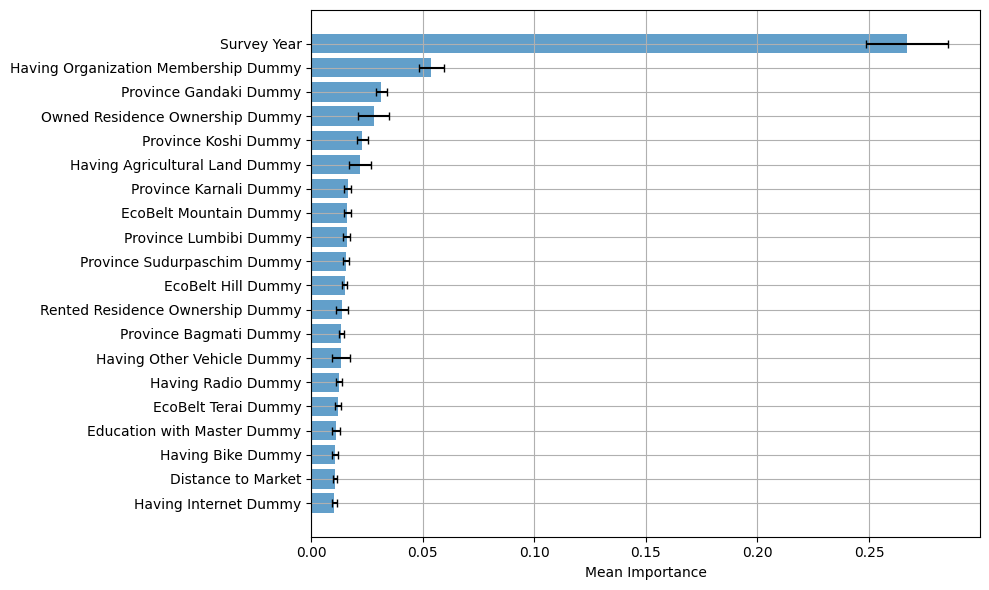

In [46]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()

plt.savefig("MLD01e_Figures/FigX_Action_RoadImprovementPast25.jpg", dpi=300, bbox_inches="tight")

plt.show()